# **IEOR 164 Project Starter Code**

by GSI Gongyu Chen (gongyu@berkeley.edu)

# **Environment Setup**

In [1]:
# For Google Colab usage: Install the Pyomo package and a solver
import sys

if 'google.colab' in sys.modules:
    %pip install pyomo >/dev/null 2>/dev/null
    %pip install highspy >/dev/null 2>/dev/null

solver = 'appsi_highs'

import pyomo.environ as pyo
SOLVER = pyo.SolverFactory(solver)

assert SOLVER.available(), f"Solver {solver} is not available."

In [2]:
# Import all packages here
from pathlib import Path
import math
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo

In [3]:
# ============================================================
# Configuration
# ============================================================

CSV_PATH = "routerbench.csv"
OUTPUT_DIR = Path("starter_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Sweep values for weighted-sum objective:
# minimize avg_cost - alpha * avg_score
ALPHA_GRID = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]

# Optional random seed not currently needed, but kept for extension.
RANDOM_SEED = 42

In [4]:
# ============================================================
# Utility functions
# ============================================================

def choose_solver():
    """
    Add your installed solver here.
    """
    candidate_solvers = ["appsi_highs"]
    for name in candidate_solvers:
        try:
            solver = pyo.SolverFactory(name)
            if solver is not None and solver.available(False):
                print(f"Using solver: {name}")
                return solver
        except Exception:
            pass
    raise RuntimeError(
        "No MILP solver found. Install HiGHS via `pip install highspy`, "
        "or install CBC/GLPK and make sure it is available to Pyomo."
    )


def safe_float(x, default=0.0):
    try:
        if pd.isna(x):
            return default
        return float(x)
    except Exception:
        return default

# **Data loading and preprocessing**

In [5]:
def load_routerbench_data(csv_path: str) -> pd.DataFrame:
    """
    Load the consolidated prompt-model dataset.

    Each row corresponds to a single prompt-model pair.

    Explanation of column fields:
      dataset: name of the benchmark dataset the prompt is sampled from.

      prompt_id: unique identifier of the prompt in the original benchmark.

      model: name of the model used to evaluate the prompt.

      score: binary performance score of the model on the prompt (0 or 1).

      cost: cost of evaluating the prompt (in dollar); if cost is zero, it means the model is open-source and can be evaluated locally without a cost-generating API call.
    """
    df = pd.read_csv(csv_path)

    required_cols = [
        "dataset", "prompt_id", "model", "score", "cost"
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"CSV is missing required columns: {missing}")

    # Normalize types
    df["dataset"] = df["dataset"].astype(str)
    df["prompt_id"] = df["prompt_id"].astype(str)
    df["model"] = df["model"].astype(str)
    df["score"] = pd.to_numeric(df["score"], errors="coerce").fillna(0.0)
    df["cost"] = pd.to_numeric(df["cost"], errors="coerce").fillna(0.0)

    # Keep one row per (prompt_id, model)
    dupes = df.duplicated(subset=["prompt_id", "model"])
    if dupes.any():
        print(
            f"Warning: found {dupes.sum()} duplicated (prompt_id, model) rows. "
            "Keeping the first occurrence."
        )
        df = df.drop_duplicates(subset=["prompt_id", "model"], keep="first").copy()

    return df


def build_prompt_weights(df: pd.DataFrame, equal_benchmark_weights: bool = True):
    """
    Construct prompt weights w_p for sample average approximation (SAA).

    By default, this function gets each prompt equal weight globally.

    You may modify this function to reflect a desired prompt distribution.
    """
    prompt_dataset = (
        df[["prompt_id", "dataset"]]
        .drop_duplicates()
        .set_index("prompt_id")["dataset"]
        .to_dict()
    )

    prompts = sorted(prompt_dataset.keys())
    datasets = sorted(set(prompt_dataset.values()))

    w = {p: 1.0 / len(prompts) for p in prompts}
    return w


def make_parameter_dicts(df: pd.DataFrame):
    """
    Create dictionaries score[(p,m)] and cost[(p,m)] for Pyomo.
    Assumes one row per (prompt_id, model).
    """
    score = {}
    cost = {}
    dataset_of_prompt = {}

    for _, row in df.iterrows():
        p = row["prompt_id"]
        m = row["model"]
        d = row["dataset"]
        score[(p, m)] = safe_float(row["score"], 0.0)
        cost[(p, m)] = safe_float(row["cost"], 0.0)
        dataset_of_prompt[p] = d

    prompts = sorted(df["prompt_id"].unique().tolist())
    models = sorted(df["model"].unique().tolist())
    datasets = sorted(df["dataset"].unique().tolist())

    return prompts, models, datasets, score, cost, dataset_of_prompt

# **Example Pyomo routing model**

In [6]:
def solve_weighted_sum_router(df: pd.DataFrame, alpha: float, prompt_weights: dict):
    """
    Decision Variables:
        x[p,m] in {0,1}: whether prompt p is assigned to model m

    Solve:
        minimize sum_p w_p sum_m x[p,m] * cost[p,m]
                 - alpha * sum_p w_p sum_m x[p,m] * score[p,m]

    s.t.
        for each prompt p: sum_m x[p,m] = 1
        x[p,m] in {0,1}

    where:
        alpha: the weight to balance the two conflicting objectives;
        prompt_weights: w_p for each prompt for approximating the expected  stochastic objective

    Interpretation:
        Choose for each prompt the best model among all possible candidate models. The result shall be interpreted as the "oracle" routing policy that you generally do not hope to beat.

        Your model should be much more complex and incorporate multiple realistic constraints to better reflect business and research considerations.
    """
    prompts, models, datasets, score, cost, dataset_of_prompt = make_parameter_dicts(df)

    # Restrict feasible assignments to those present in data
    available_pairs = sorted(score.keys())

    model = pyo.ConcreteModel()

    model.P = pyo.Set(initialize=prompts)
    model.M = pyo.Set(initialize=models)
    model.PM = pyo.Set(initialize=available_pairs, dimen=2)

    model.w = pyo.Param(model.P, initialize=prompt_weights, within=pyo.NonNegativeReals)
    model.score = pyo.Param(model.PM, initialize=score, within=pyo.Reals)
    model.cost = pyo.Param(model.PM, initialize=cost, within=pyo.NonNegativeReals)

    model.x = pyo.Var(model.PM, within=pyo.Binary)

    def assignment_rule(mdl, p):
        feasible_models = [mm for (pp, mm) in mdl.PM if pp == p]
        return sum(mdl.x[p, mm] for mm in feasible_models) == 1

    model.assignment = pyo.Constraint(model.P, rule=assignment_rule)

    def objective_rule(mdl):
        avg_cost = sum(mdl.w[p] * mdl.cost[p, m] * mdl.x[p, m] for (p, m) in mdl.PM)
        avg_score = sum(mdl.w[p] * mdl.score[p, m] * mdl.x[p, m] for (p, m) in mdl.PM)
        return avg_cost - alpha * avg_score

    model.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

    solver = choose_solver()
    results = solver.solve(model, tee=False)

    # Extract chosen routes
    chosen_rows = []
    for (p, m) in model.PM:
        if pyo.value(model.x[p, m]) > 0.5:
            chosen_rows.append({
                "prompt_id": p,
                "model": m,
                "dataset": dataset_of_prompt[p],
                "weight": prompt_weights[p],
                "score": score[(p, m)],
                "cost": cost[(p, m)],
            })

    chosen_df = pd.DataFrame(chosen_rows).sort_values(["dataset", "prompt_id"]).reset_index(drop=True)

    avg_cost = float((chosen_df["weight"] * chosen_df["cost"]).sum())
    avg_score = float((chosen_df["weight"] * chosen_df["score"]).sum())
    objective_value = avg_cost - alpha * avg_score

    return {
        "alpha": alpha,
        "policy_name": "Oracle Routing",
        "avg_cost": avg_cost,
        "avg_score": avg_score,
        "objective_value": objective_value,
        "assignments": chosen_df,
        "solver_status": str(results.solver.status),
        "termination_condition": str(results.solver.termination_condition),
    }

In [7]:
# ============================================================
# Additional baseline policies

# These reflects the most naive policies that your optimal solution should  outperform.
# ============================================================

def evaluate_single_best(df: pd.DataFrame, alpha: float, prompt_weights: dict):
    """
    Choose one model for all prompts using the same decision metric {Cost - alph * Score}.
    """
    prompts, models, datasets, score, cost, dataset_of_prompt = make_parameter_dicts(df)

    rows = []
    for m in models:
        sub = df[df["model"] == m].copy()

        # Need coverage for every prompt
        covered_prompts = set(sub["prompt_id"])
        if covered_prompts != set(prompts):
            continue

        weighted_cost = 0.0
        weighted_score = 0.0
        for _, r in sub.iterrows():
            p = r["prompt_id"]
            weighted_cost += prompt_weights[p] * float(r["cost"])
            weighted_score += prompt_weights[p] * float(r["score"])

        obj = weighted_cost - alpha * weighted_score
        rows.append({
            "alpha": alpha,
            "model": m,
            "avg_cost": weighted_cost,
            "avg_score": weighted_score,
            "objective_value": obj,
        })

    if not rows:
        raise RuntimeError("No model covers all prompts for the Single Best baseline.")

    cand = pd.DataFrame(rows).sort_values("objective_value").reset_index(drop=True)
    best_model = cand.loc[0, "model"]
    best_cost = float(cand.loc[0, "avg_cost"])
    best_score = float(cand.loc[0, "avg_score"])
    best_obj = float(cand.loc[0, "objective_value"])

    assignment_df = df[df["model"] == best_model][["prompt_id", "dataset", "model", "score", "cost"]].copy()
    assignment_df["weight"] = assignment_df["prompt_id"].map(prompt_weights)

    return {
        "alpha": alpha,
        "policy_name": "Single Best",
        "selected_model": best_model,
        "avg_cost": best_cost,
        "avg_score": best_score,
        "objective_value": best_obj,
        "assignments": assignment_df.sort_values(["dataset", "prompt_id"]).reset_index(drop=True),
    }


def evaluate_single_best_per_benchmark(df: pd.DataFrame, alpha: float, prompt_weights: dict):
    """
    For each benchmark dataset, choose one model used for all prompts in that dataset.
    """
    prompts, models, datasets, score, cost, dataset_of_prompt = make_parameter_dicts(df)

    selected_models = {}
    assignment_rows = []

    for d in datasets:
        df_d = df[df["dataset"] == d].copy()
        prompts_d = sorted(df_d["prompt_id"].unique().tolist())

        rows = []
        for m in models:
            sub = df_d[df_d["model"] == m].copy()

            if set(sub["prompt_id"]) != set(prompts_d):
                continue

            weighted_cost = 0.0
            weighted_score = 0.0
            for _, r in sub.iterrows():
                p = r["prompt_id"]
                weighted_cost += prompt_weights[p] * float(r["cost"])
                weighted_score += prompt_weights[p] * float(r["score"])

            obj = weighted_cost - alpha * weighted_score
            rows.append({
                "dataset": d,
                "model": m,
                "avg_cost_dataset_contrib": weighted_cost,
                "avg_score_dataset_contrib": weighted_score,
                "objective_value_dataset_contrib": obj,
            })

        if not rows:
            raise RuntimeError(f"No model covers all prompts in dataset {d}.")

        cand = pd.DataFrame(rows).sort_values("objective_value_dataset_contrib").reset_index(drop=True)
        best_model = cand.loc[0, "model"]
        selected_models[d] = best_model

        chosen = df_d[df_d["model"] == best_model][["prompt_id", "dataset", "model", "score", "cost"]].copy()
        chosen["weight"] = chosen["prompt_id"].map(prompt_weights)
        assignment_rows.append(chosen)

    assignment_df = pd.concat(assignment_rows, ignore_index=True)
    avg_cost = float((assignment_df["weight"] * assignment_df["cost"]).sum())
    avg_score = float((assignment_df["weight"] * assignment_df["score"]).sum())
    obj = avg_cost - alpha * avg_score

    return {
        "alpha": alpha,
        "policy_name": "Single Best per Benchmark",
        "selected_models_by_dataset": selected_models,
        "avg_cost": avg_cost,
        "avg_score": avg_score,
        "objective_value": obj,
        "assignments": assignment_df.sort_values(["dataset", "prompt_id"]).reset_index(drop=True),
    }

# **Plotting Functionality**

In [8]:
def plot_frontier(results_df: pd.DataFrame, output_path: Path):
    """
    Scatter/line plot on the cost-performance plane.
    x-axis: average cost (weighted by prompt-weights)
    y-axis: average score (weighted by prompt-weights)
    """
    plt.figure(figsize=(10, 7))

    # Oracle weighted-sum routing frontier
    opt = results_df[results_df["policy_name"] == "Oracle Routing"].sort_values("alpha")
    plt.plot(opt["avg_cost"], opt["avg_score"], marker="o", linewidth=2, label="Oracle Routing")

    # for _, row in opt.iterrows():
    #     plt.annotate(
    #         f"a={row['alpha']}",
    #         (row["avg_cost"], row["avg_score"]),
    #         textcoords="offset points",
    #         xytext=(5, 5),
    #         fontsize=8
    #     )

    # Single Best baseline
    sb = results_df[results_df["policy_name"] == "Single Best"].sort_values("alpha")
    plt.plot(sb["avg_cost"], sb["avg_score"], marker="s", linestyle="--", linewidth=1.5, label="Single Best")

    # Single Best per Benchmark baseline
    sbb = results_df[results_df["policy_name"] == "Single Best per Benchmark"].sort_values("alpha")
    plt.plot(
        sbb["avg_cost"], sbb["avg_score"],
        marker="^", linestyle="--", linewidth=1.5,
        label="Single Best per Benchmark"
    )

    '''
    ADD YOUR SOLUTION HERE TO BE PLOTTED ON THE SAME GRAPH
    '''

    plt.xlabel("Weighted Average Cost")
    plt.ylabel("Weighted Average Performance (Score)")
    plt.title("Routing Policies on the Cost-Performance Plane")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()

# **Your Implementation**

Implement your model here.

# **Experiments**

Loading data...

Basic dataset summary
--------------------------------------------------
Rows: 7,860
Unique prompts: 240
Unique models: 33

Prompts by dataset:
dataset
AIME        60
GPQA        60
LCB         60
MMLU-Pro    60
Name: count, dtype: int64

Weighting scheme
--------------------------------------------------
Total prompt weight = 1.000000

Solving for alpha = 0.01
Using solver: appsi_highs
  Oracle Routing            -> cost=0.000162, score=0.958333
  Single Best                -> cost=0.000000, score=0.616667, model=MiniCPM4.1-8B
  Single Best per Benchmark  -> cost=0.000665, score=0.750000

Solving for alpha = 0.05
Using solver: appsi_highs
  Oracle Routing            -> cost=0.000595, score=0.970833
  Single Best                -> cost=0.001756, score=0.729167, model=qwen3-235b-a22b-2507
  Single Best per Benchmark  -> cost=0.001733, score=0.816667

Solving for alpha = 0.1
Using solver: appsi_highs
  Oracle Routing            -> cost=0.001222, score=0.979167
  Single B

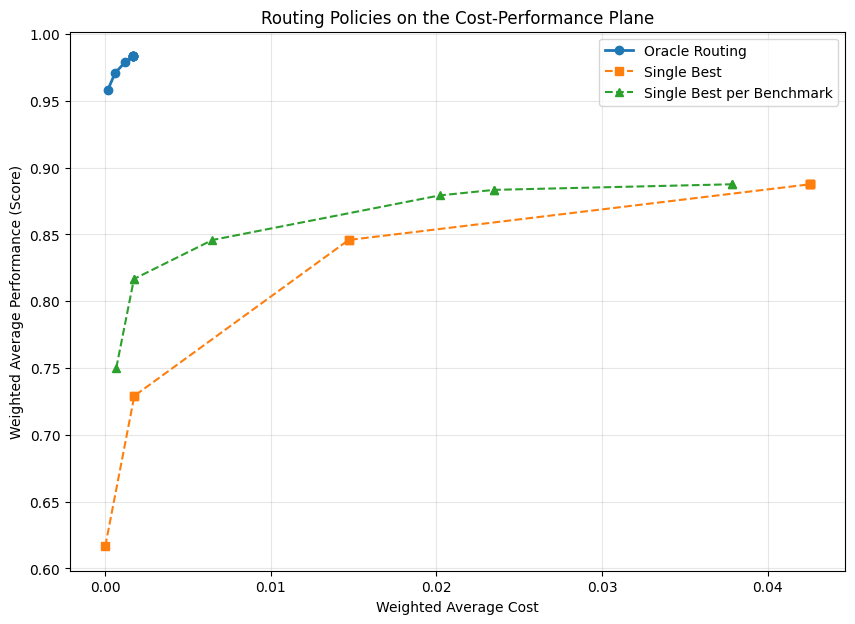


Saved outputs:
  starter_outputs/policy_summary.csv
  starter_outputs/cost_performance_frontier.png
  starter_outputs


In [9]:
def main():
    print("Loading data...")
    df = load_routerbench_data(CSV_PATH)

    print("\nBasic dataset summary")
    print("-" * 50)
    print(f"Rows: {len(df):,}")
    print(f"Unique prompts: {df['prompt_id'].nunique():,}")
    print(f"Unique models: {df['model'].nunique():,}")
    print("\nPrompts by dataset:")
    print(df[["prompt_id", "dataset"]].drop_duplicates()["dataset"].value_counts().sort_index())

    prompt_weights = build_prompt_weights(df)

    print("\nWeighting scheme")
    print("-" * 50)
    print(f"Total prompt weight = {sum(prompt_weights.values()):.6f}")

    policy_records = []
    example_assignment_saved = False

    # The oracle router and the baseline policies are defined over a range of alpha
    for alpha in ALPHA_GRID:
        print(f"\nSolving for alpha = {alpha}")

        # 1) Oracle routing
        optimal_result = solve_weighted_sum_router(df, alpha, prompt_weights)
        policy_records.append({
            "alpha": alpha,
            "policy_name": optimal_result["policy_name"],
            "avg_cost": optimal_result["avg_cost"],
            "avg_score": optimal_result["avg_score"],
            "objective_value": optimal_result["objective_value"],
            "details": "",
        })

        # Save one sample assignment table
        if not example_assignment_saved:
            assignment_path = OUTPUT_DIR / f"optimal_assignments_alpha_{str(alpha).replace('.', '_')}.csv"
            optimal_result["assignments"].to_csv(assignment_path, index=False)
            example_assignment_saved = True

        # 2) Single Best baseline
        sb_result = evaluate_single_best(df, alpha, prompt_weights)
        policy_records.append({
            "alpha": alpha,
            "policy_name": sb_result["policy_name"],
            "avg_cost": sb_result["avg_cost"],
            "avg_score": sb_result["avg_score"],
            "objective_value": sb_result["objective_value"],
            "details": f"model={sb_result['selected_model']}",
        })

        # 3) Single Best per Benchmark baseline
        sbb_result = evaluate_single_best_per_benchmark(df, alpha, prompt_weights)
        selected_str = "; ".join([f"{d}:{m}" for d, m in sorted(sbb_result["selected_models_by_dataset"].items())])
        policy_records.append({
            "alpha": alpha,
            "policy_name": sbb_result["policy_name"],
            "avg_cost": sbb_result["avg_cost"],
            "avg_score": sbb_result["avg_score"],
            "objective_value": sbb_result["objective_value"],
            "details": selected_str,
        })

        print(
            f"  Oracle Routing            -> cost={optimal_result['avg_cost']:.6f}, "
            f"score={optimal_result['avg_score']:.6f}"
        )
        print(
            f"  Single Best                -> cost={sb_result['avg_cost']:.6f}, "
            f"score={sb_result['avg_score']:.6f}, model={sb_result['selected_model']}"
        )
        print(
            f"  Single Best per Benchmark  -> cost={sbb_result['avg_cost']:.6f}, "
            f"score={sbb_result['avg_score']:.6f}"
        )

    results_df = pd.DataFrame(policy_records)

    print("\nFinal policy table")
    print("-" * 50)
    print(results_df)

    summary_path = OUTPUT_DIR / "policy_summary.csv"
    results_df.to_csv(summary_path, index=False)

    plot_path = OUTPUT_DIR / "cost_performance_frontier.png"
    plot_frontier(results_df, plot_path)

    print("\nSaved outputs:")
    print(f"  {summary_path}")
    print(f"  {plot_path}")
    print(f"  {OUTPUT_DIR}")


if __name__ == "__main__":
    main()